In [ ]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project"
RAW_DIR = f"{BASE_DIR}/data/raw"

sources = ["nasa_power", "gpm_imerg", "era5", "imd"]

print("🔍 Checking raw data folders...\n")

for src in sources:
    path = os.path.join(RAW_DIR, src)
    if not os.path.exists(path):
        raise RuntimeError(f"Missing required folder: {path}")

    file_count = 0
    for root, _, files in os.walk(path):
        file_count += len(files)

    print(f"{src}: folder exists | files detected = {file_count}")

# Create checkpoint flag
CHECKPOINT_FILE = f"{BASE_DIR}/logs/phase_1_completed.flag"
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

with open(CHECKPOINT_FILE, "w") as f:
    f.write("Phase 1 data collection completed and verified.\n")

print("\n✅ Phase 1 checkpoint created successfully.")
print("You can now proceed to Phase 2 without rerunning Phase 1.")


Mounted at /content/drive
🔍 Checking raw data folders...

nasa_power: folder exists | files detected = 73
gpm_imerg: folder exists | files detected = 1
era5: folder exists | files detected = 12
imd: folder exists | files detected = 0

✅ Phase 1 checkpoint created successfully.
You can now proceed to Phase 2 without rerunning Phase 1.


In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project"
NASA_DIR = f"{BASE_DIR}/data/raw/nasa_power"

dfs = []

for file in os.listdir(NASA_DIR):
    if file.endswith(".csv"):
        district = file.replace("nasa_power_", "").replace("_raw.csv", "")
        df = pd.read_csv(os.path.join(NASA_DIR, file))

        df["district"] = district
        df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d")

        dfs.append(df)

nasa_all = pd.concat(dfs, ignore_index=True)
nasa_all.columns = [c.lower() for c in nasa_all.columns]

print("NASA POWER combined shape:", nasa_all.shape)
print("Districts loaded:", nasa_all["district"].nunique())
print("Date range:", nasa_all["date"].min(), "to", nasa_all["date"].max())


NASA POWER combined shape: (237688, 10)
Districts loaded: 73
Date range: 2017-01-01 00:00:00 to 2025-11-30 00:00:00


In [ ]:
import pandas as pd

districts = nasa_all["district"].unique()
all_dates = pd.date_range(
    start=nasa_all["date"].min(),
    end=nasa_all["date"].max(),
    freq="D"
)

skeleton = (
    pd.MultiIndex.from_product(
        [districts, all_dates],
        names=["district", "date"]
    )
    .to_frame(index=False)
)

nasa_aligned = skeleton.merge(
    nasa_all,
    on=["district", "date"],
    how="left"
)

print("Skeleton shape:", skeleton.shape)
print("Aligned NASA POWER shape:", nasa_aligned.shape)
print("Missing rows after alignment:", nasa_aligned.isna().any(axis=1).sum())


Skeleton shape: (237688, 2)
Aligned NASA POWER shape: (237688, 10)
Missing rows after alignment: 0


In [ ]:
# Phase 2
# WHY: Robustly locate and load district_coordinates.csv without path errors

import os
import pandas as pd

# 1. Ensure Drive is mounted
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive"

# 2. Search for district_coordinates.csv safely
district_file_path = None

for root, dirs, files in os.walk(BASE_DIR):
    if "district_coordinates.csv" in files:
        district_file_path = os.path.join(root, "district_coordinates.csv")
        break

if district_file_path is None:
    raise FileNotFoundError("district_coordinates.csv NOT found anywhere in MyDrive")

print("✅ Found district coordinate file at:")
print(district_file_path)

# 3. Load file
districts = pd.read_csv(district_file_path)

# 4. Standardize district names
districts["district"] = (
    districts["district"]
    .str.lower()
    .str.replace(" ", "_")
)

print("\nLoaded district coordinates")
print("Shape:", districts.shape)
districts.head()


Mounted at /content/drive
✅ Found district coordinate file at:
/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/raw/district_coordinates.csv

Loaded district coordinates
Shape: (72, 3)


,district,latitude,longitude
0,agra,27.1767,78.0081
1,aligarh,27.8974,78.0880
2,ambedkar_nagar,26.4050,82.5400
3,amethi,26.1542,81.8140
4,amroha,28.9044,78.4670


In [ ]:
# Phase 2
# WHY: Merge ERA5 instant + accumulated variables safely across all years

import xarray as xr
import pandas as pd
import zipfile
import tempfile
import os

ERA5_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/raw/era5"

era5_files = sorted([
    os.path.join(ERA5_DIR, f)
    for f in os.listdir(ERA5_DIR)
    if f.startswith("era5_") and f.endswith(".nc")
])

print("ERA5 yearly files detected:", len(era5_files))

era5_all_years = []

for zip_nc in era5_files:
    year = zip_nc.split("_")[-1].replace(".nc", "")
    print(f"Processing ERA5 year: {year}")

    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_nc, "r") as z:
            z.extractall(tmpdir)

        inst = os.path.join(tmpdir, "data_stream-oper_stepType-instant.nc")
        acc  = os.path.join(tmpdir, "data_stream-oper_stepType-accum.nc")

        if not (os.path.exists(inst) and os.path.exists(acc)):
            print(f"⚠️ Skipping {year} (missing files)")
            continue

        ds_inst = xr.open_dataset(inst, engine="h5netcdf")
        ds_acc  = xr.open_dataset(acc, engine="h5netcdf")

        # ✅ FIX: override metadata conflicts (expver)
        ds = xr.merge([ds_inst, ds_acc], compat="override")

        df = ds.to_dataframe().reset_index()
        df["year"] = int(year)

        era5_all_years.append(df)

era5_raw = pd.concat(era5_all_years, ignore_index=True)

era5_raw = era5_raw.rename(columns={"valid_time": "date"})
era5_raw["date"] = pd.to_datetime(era5_raw["date"]).dt.date

print("✅ ERA5 raw combined shape:", era5_raw.shape)
era5_raw.head()


ERA5 yearly files detected: 10
Processing ERA5 year: 2017
Processing ERA5 year: 2018
Processing ERA5 year: 2019
Processing ERA5 year: 2020
Processing ERA5 year: 2021
Processing ERA5 year: 2022
Processing ERA5 year: 2023
Processing ERA5 year: 2024
Processing ERA5 year: 2025
Processing ERA5 year: 20170101
✅ ERA5 raw combined shape: (3546873, 12)


,date,latitude,longitude,sp,t2m,d2m,u10,v10,number,expver,tp,year
0,2017-01-01,31.0,77.00,89131.46875,280.371490,277.967285,-1.242950,-0.295624,0,0001,0.000000e+00,2017
1,2017-01-01,31.0,77.25,83438.46875,277.588287,275.535645,-1.308380,0.269806,0,0001,4.768372e-07,2017
2,2017-01-01,31.0,77.50,80223.46875,274.646881,273.400879,-1.131622,0.470978,0,0001,9.536743e-07,2017
3,2017-01-01,31.0,77.75,79704.46875,275.381256,271.762207,-0.744904,-0.875702,0,0001,0.000000e+00,2017
4,2017-01-01,31.0,78.00,76434.46875,273.211334,266.691895,-0.893341,-1.484100,0,0001,0.000000e+00,2017


In [ ]:
# Phase 2
# WHY: Convert ERA5 gridded data into district-level daily dataset

import numpy as np
import pandas as pd

# --- Select only required ERA5 columns ---
era5_use = era5_raw[
    ["date", "latitude", "longitude", "t2m", "d2m", "sp", "u10", "v10", "tp"]
].copy()

# --- Function to get nearest grid value for one district ---
def extract_district_era5(df, lat, lon):
    dist = (df["latitude"] - lat)**2 + (df["longitude"] - lon)**2
    nearest_idx = dist.idxmin()
    return df.loc[nearest_idx]

district_era5_rows = []

# --- Loop over districts ---
for _, d in districts.iterrows():
    dname = d["district"]
    dlat  = d["latitude"]
    dlon  = d["longitude"]

    # Filter ERA5 roughly around district (speed-up)
    sub = era5_use[
        (era5_use["latitude"].between(dlat-0.5, dlat+0.5)) &
        (era5_use["longitude"].between(dlon-0.5, dlon+0.5))
    ]

    # Group by date and extract nearest grid per day
    daily = (
        sub.groupby("date", group_keys=False)
           .apply(lambda x: extract_district_era5(x, dlat, dlon))
           .reset_index(drop=True)
    )

    daily["district"] = dname
    district_era5_rows.append(daily)

# --- Combine all districts ---
era5_district_daily = pd.concat(district_era5_rows, ignore_index=True)

# --- Reorder columns ---
era5_district_daily = era5_district_daily[
    ["district", "date", "t2m", "d2m", "sp", "u10", "v10", "tp"]
]

print("✅ ERA5 district-level shape:", era5_district_daily.shape)
print("Districts:", era5_district_daily["district"].nunique())
print("Date range:", era5_district_daily["date"].min(), "to", era5_district_daily["date"].max())

era5_district_daily.head()


/tmp/ipython-input-895904391.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: extract_district_era5(x, dlat, dlon))
/tmp/ipython-input-895904391.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: extract_district_era5(x, dlat, dlon))
/tmp/ipython-input-895904391.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

✅ ERA5 district-level shape: (234432, 8)
Districts: 72
Date range: 2017-01-01 to 2025-11-30


/tmp/ipython-input-895904391.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: extract_district_era5(x, dlat, dlon))


,district,date,t2m,d2m,sp,u10,v10,tp
0,agra,2017-01-01,283.988678,283.344238,99542.468750,-1.707794,0.345978,0.0
1,agra,2017-01-02,285.461639,285.158386,99623.601562,-1.317856,-1.254608,0.0
2,agra,2017-01-03,284.183411,283.839050,99805.359375,0.872009,-0.787140,0.0
3,agra,2017-01-04,282.857788,282.644440,99603.609375,2.238419,0.960968,0.0
4,agra,2017-01-05,283.694061,283.315094,99517.437500,0.115295,1.745438,0.0


In [ ]:
import pandas as pd
import os

NASA_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/raw/nasa_power"
OUT_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/nasa_power_combined.csv"

all_dfs = []

for fname in os.listdir(NASA_DIR):
    if fname.endswith("_raw.csv"):
        fpath = os.path.join(NASA_DIR, fname)

        # extract district name from filename
        district = fname.replace("nasa_power_", "").replace("_raw.csv", "")

        df = pd.read_csv(fpath, parse_dates=["date"])
        df["district"] = district

        all_dfs.append(df)

nasa_combined = pd.concat(all_dfs, ignore_index=True)

# sort for safety
nasa_combined = nasa_combined.sort_values(["district", "date"]).reset_index(drop=True)

# save
nasa_combined.to_csv(OUT_PATH, index=False)

print("✅ NASA POWER combined successfully")
print("Shape:", nasa_combined.shape)
print("Districts:", nasa_combined["district"].nunique())
print("Date range:", nasa_combined["date"].min(), "to", nasa_combined["date"].max())

nasa_combined.head()


✅ NASA POWER combined successfully
Shape: (237688, 10)
Districts: 73
Date range: 2017-01-01 00:00:00 to 2025-11-30 00:00:00


,date,PRECTOTCORR,RH2M,T2MDEW,PS,WS10M,WS50M,WD10M,WD50M,district
0,2017-01-01,0.0,58.76,6.32,99.68,2.26,3.34,104.4,107.4,agra
1,2017-01-02,0.0,57.88,6.45,99.87,2.28,3.33,354.9,354.0,agra
2,2017-01-03,0.0,52.82,5.76,99.90,1.62,2.40,326.3,327.0,agra
3,2017-01-04,0.0,41.44,3.98,99.70,1.60,2.11,222.5,224.6,agra
4,2017-01-05,0.0,35.74,2.01,99.56,1.87,2.56,251.0,249.4,agra


✅ NASA POWER aligned to ERA5 date range
Shape: (237688, 10)
Districts: 73
Date range: 2017-01-01 00:00:00 to 2025-11-30 00:00:00


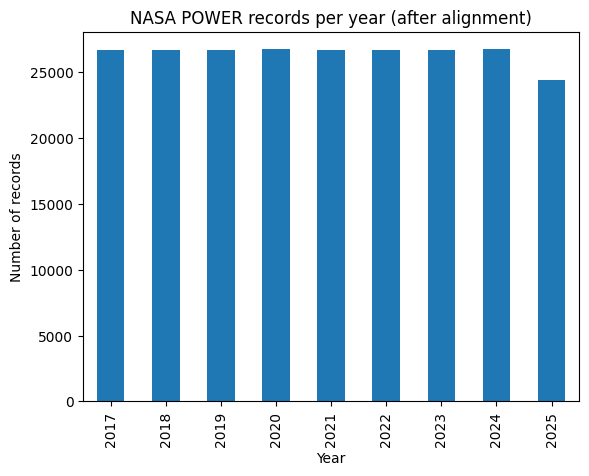

,date,PRECTOTCORR,RH2M,T2MDEW,PS,WS10M,WS50M,WD10M,WD50M,district
0,2017-01-01,0.0,58.76,6.32,99.68,2.26,3.34,104.4,107.4,agra
1,2017-01-02,0.0,57.88,6.45,99.87,2.28,3.33,354.9,354.0,agra
2,2017-01-03,0.0,52.82,5.76,99.90,1.62,2.40,326.3,327.0,agra
3,2017-01-04,0.0,41.44,3.98,99.70,1.60,2.11,222.5,224.6,agra
4,2017-01-05,0.0,35.74,2.01,99.56,1.87,2.56,251.0,249.4,agra


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths
NASA_COMBINED_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/nasa_power_combined.csv"
NASA_ALIGNED_PATH  = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/nasa_power_aligned.csv"

# Load combined NASA data
nasa = pd.read_csv(NASA_COMBINED_PATH, parse_dates=["date"])

# Explicitly align to ERA5-supported period
START_DATE = "2017-01-01"
END_DATE   = "2025-11-30"

nasa_aligned = nasa[
    (nasa["date"] >= START_DATE) &
    (nasa["date"] <= END_DATE)
].copy()

# Save aligned data
nasa_aligned.to_csv(NASA_ALIGNED_PATH, index=False)

print("✅ NASA POWER aligned to ERA5 date range")
print("Shape:", nasa_aligned.shape)
print("Districts:", nasa_aligned["district"].nunique())
print("Date range:", nasa_aligned["date"].min(), "to", nasa_aligned["date"].max())

# -------------------------
# Simple visualization
# -------------------------
rows_per_year = nasa_aligned["date"].dt.year.value_counts().sort_index()

plt.figure()
rows_per_year.plot(kind="bar")
plt.title("NASA POWER records per year (after alignment)")
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.show()

nasa_aligned.head()


In [ ]:
# =========================================
# Phase 2 – Cell: Save ERA5 district daily
# =========================================

ERA5_OUT_PATH = (
    "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/"
    "data/raw/era5/era5_district_daily_2017_2025.csv"
)

era5_district_daily.to_csv(ERA5_OUT_PATH, index=False)

print("✅ ERA5 district daily dataset saved")
print("Path:", ERA5_OUT_PATH)
print("Shape:", era5_district_daily.shape)
print("Districts:", era5_district_daily['district'].nunique())
print(
    "Date range:",
    era5_district_daily['date'].min(),
    "to",
    era5_district_daily['date'].max()
)


✅ ERA5 district daily dataset saved
Path: /content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/raw/era5/era5_district_daily_2017_2025.csv
Shape: (234432, 8)
Districts: 72
Date range: 2017-01-01 to 2025-11-30


In [ ]:
import pandas as pd

# ----------------------------
# Paths
# ----------------------------
NASA_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/nasa_power_aligned.csv"
ERA5_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/raw/era5/era5_district_daily_2017_2025.csv"
OUT_PATH  = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/merged_nasa_era5_daily_2017_2025.csv"

# ----------------------------
# Load datasets
# ----------------------------
nasa = pd.read_csv(NASA_PATH, parse_dates=["date"])
era5 = pd.read_csv(ERA5_PATH, parse_dates=["date"])

# ----------------------------
# Standardize district names
# ----------------------------
nasa["district"] = nasa["district"].str.lower().str.strip()
era5["district"] = era5["district"].str.lower().str.strip()

# ----------------------------
# Merge (LEFT JOIN keeps all NASA districts)
# ----------------------------
merged = nasa.merge(
    era5,
    on=["district", "date"],
    how="left"
)

# ----------------------------
# Save final Phase-2 output
# ----------------------------
merged.to_csv(OUT_PATH, index=False)

# ----------------------------
# Summary
# ----------------------------
print("✅ Phase 2 merge completed")
print("Final shape:", merged.shape)
print("Districts:", merged['district'].nunique())
print("Date range:", merged['date'].min(), "to", merged['date'].max())

missing_era5 = merged["t2m"].isna().sum()
print("Rows with missing ERA5 values:", missing_era5)
print("Saved to:", OUT_PATH)


✅ Phase 2 merge completed
Final shape: (237688, 16)
Districts: 73
Date range: 2017-01-01 00:00:00 to 2025-11-30 00:00:00
Rows with missing ERA5 values: 3256
Saved to: /content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/cleaned/merged_nasa_era5_daily_2017_2025.csv
